# Module 2 - Forecast Error Analysis
## Medcore Pharma | Demand Planning Intelligence

Objective - Detect and quantify forecast anomalies that the current S&OP process does not catch.

Key outputs :
- MAPE and bias per SKU (not global averages)
- Cumulative bias tren - distinguishing punctual error from structural drift
- Forecast performance by source : Actual Sales vs Algorithm forecast
- Financial impact : excess stock and stockout cost in Euros
- SKU risk score for s&OP priorization

Stack : pandas, numpy and SQLITE

In [1]:
# Cell 1 : Imports + database connection

import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns

# establish connection and load tables
DB_PATH = os.path.join("..","data","medcore.db")
conn = sqlite3.connect(DB_PATH)

df_products = pd.read_sql("SELECT * FROM product_master", conn)
df_demand = pd.read_sql("SELECT * FROM demand_history", conn)
df_forecast = pd.read_sql("SELECT * FROM forecast_history", conn)

print(f"product_master :{len(df_products)} rows")
print(f"demand history : {len(df_demand)} rows")
print(f"forecast_history : {len(df_forecast)} rows")
print("\nAll tables loaded.")


product_master :50 rows
demand history : 7600 rows
forecast_history : 7600 rows

All tables loaded.


In [2]:
# Cell 2 : Merge tables into one working Dataframe
#we join demand, forecast and product attributes on sku + week
# This gives one row per SKU per week with everythng we need to calculate errors
df_products.columns = df_products.columns.str.lower()

# step 1 - merge demand and forecast on sku_id + week
df = pd.merge(
    df_demand,
    df_forecast,
    on = ["sku_id","week"],
    how = "inner"
)

# Step 2 - Add product attributes (family, market, unit_cost, flags per line)
df = pd.merge(
    df,
    df_products,
    on = "sku_id",
    how = "left"
)

#step 3 - Convert week column to datetime
df["week"] = pd.to_datetime(df["week"])

#check

print(f"Merged Dataframe : {len(df)} rows x {len(df.columns)} columns")
print(f"Columns : {list(df.columns)}")
print(f"\nFirst 5 rows :")
df.head()

Merged Dataframe : 7600 rows x 16 columns
Columns : ['sku_id', 'week', 'actual_demand', 'stock_on_hand', 'outlier_type', 'week_number', 'sales_forecast', 'algo_forecast', 'final_forecast', 'forecast_source', 'family', 'market', 'unit_cost', 'has_bias', 'has_seasonality', 'has_bullwhip']

First 5 rows :


,sku_id,week,actual_demand,stock_on_hand,outlier_type,week_number,sales_forecast,algo_forecast,final_forecast,forecast_source,family,market,unit_cost,has_bias,has_seasonality,has_bullwhip
0,SKU-001,2022-02-07,19,101,none,6,19,15,19,Sales,Medical Devices,Benelux,717.85,0,1,0
1,SKU-001,2022-02-14,23,78,none,7,23,15,23,Sales,Medical Devices,Benelux,717.85,0,1,0
2,SKU-001,2022-02-21,21,57,none,8,21,15,15,Algo,Medical Devices,Benelux,717.85,0,1,0
3,SKU-001,2022-02-28,12,45,none,9,12,15,15,Algo,Medical Devices,Benelux,717.85,0,1,0
4,SKU-001,2022-03-07,18,27,none,10,18,19,18,Sales,Medical Devices,Benelux,717.85,0,1,0


In [3]:
# Cell 3 : MAPE & Bias calculation per SKU
# MAPE measures the magnitude of error (always positive)
# Bias measures the direction of error (positive = over-forecast, negative = under-forecast)

# Step 1 - Calculate error metrics at row level
df["error"] = df["final_forecast"] - df["actual_demand"]
df["abs_error"] = df["error"].abs()
df["pct_error"] = df["abs_error"] / df["actual_demand"].replace(0,np.nan)
df["bias_pct"] = df["error"] / df["actual_demand"].replace(0, np.nan)
                    
                    
#Step 2 - Aggregate by SKU
sku_performance = df.groupby("sku_id").agg(
    family = ("family", "first"),
    market = ("market", "first"),
    unit_cost = ("unit_cost", "first"),
    has_bias_flag = ("has_bias", "first"),
    has_seasonality = ("has_seasonality", "first"),
    has_bullwhip    = ("has_bullwhip", "first"),
    avg_demand      = ("actual_demand", "mean"),
    mape            = ("pct_error", "mean"),
    bias            = ("bias_pct", "mean"),
    total_weeks     = ("week", "count")
).reset_index()

# convert to percentage and round
sku_performance["mape"] = (sku_performance["mape"] * 100).round(1)
sku_performance["bias"] = (sku_performance["bias"] * 100).round(1)

# Sort by worst bias first
sku_performance = sku_performance.sort_values("bias",ascending=False)

print(f"SKU performance table : {len(sku_performance)} SKUs")
print(f"\nGlobal MAPE (avergae across SKUs) : {sku_performance['mape'].mean():.1f}%")
print(f"Global Bias (average across SKUs) : {sku_performance['bias'].mean():.1f}%")
print(f"\nTop 5 worst bias (over-forecast) :")
sku_performance.head()

SKU performance table : 50 SKUs

Global MAPE (avergae across SKUs) : 14.1%
Global Bias (average across SKUs) : 8.9%

Top 5 worst bias (over-forecast) :


,sku_id,family,market,unit_cost,has_bias_flag,has_seasonality,has_bullwhip,avg_demand,mape,bias,total_weeks
41,SKU-042,Diagnostic Equipment,Germany,1883.36,1,0,0,11.934211,24.6,20.0,152
23,SKU-024,Surgical Consumables,France,41.28,1,1,0,220.381579,24.3,19.7,152
18,SKU-019,Medical Devices,Benelux,815.80,1,0,0,16.980263,23.8,19.6,152
12,SKU-013,Medical Devices,Benelux,927.90,1,0,0,16.861842,23.2,18.9,152
29,SKU-030,Surgical Consumables,Benelux,44.75,1,0,0,217.157895,23.2,18.6,152


In [4]:
# Cell 4 : Financial impact
# During Demand planning meetings, talking in quantities might be better but for S&OP meetings where decisions are taken,
#  it is important to understand the financial impact of the strategy
# We translate here forecast bias into euros
# Excess stock cost : over-forecast generates stock that shouldn't be there
# Stockout risk cost : under-forecast generates potential lost service

# Step 1 — Excess stock value per SKU
# Logic : if bias is positive (over-forecast), excess stock = avg weekly demand x bias% x unit_cost x 52 weeks
sku_performance["excess_stock_units"] = (
    sku_performance["avg_demand"] *
    (sku_performance["bias"] / 100).clip(lower=0) *  # only positive bias
    52  # annualized
).round(0)

sku_performance["excess_stock_eur"] = (
    sku_performance["excess_stock_units"] * sku_performance["unit_cost"]
).round(0)

# Step 2 — Stockout risk per SKU
# Logic : if bias is negative (under-forecast), unserved volume = avg demand x abs(bias%) x 52 weeks
sku_performance["stockout_risk_units"] = (
    sku_performance["avg_demand"] *
    (sku_performance["bias"] / 100).clip(upper=0).abs() *  # only negative bias
    52
).round(0)

sku_performance["stockout_risk_eur"] = (
    sku_performance["stockout_risk_units"] * sku_performance["unit_cost"]
).round(0)

# Step 3 — Summary
total_excess_eur   = sku_performance["excess_stock_eur"].sum()
total_stockout_eur = sku_performance["stockout_risk_eur"].sum()

print(f"Total excess stock value    : €{total_excess_eur:,.0f}")
print(f"Total stockout risk value   : €{total_stockout_eur:,.0f}")
print(f"Combined financial exposure : €{total_excess_eur + total_stockout_eur:,.0f}")
print(f"\nTop 5 SKUs by excess stock value :")
sku_performance.sort_values("excess_stock_eur", ascending=False)[
    ["sku_id", "family", "market", "bias", "mape", "excess_stock_eur", "stockout_risk_eur"]
].head()

Total excess stock value    : €3,158,858
Total stockout risk value   : €2,496
Combined financial exposure : €3,161,354

Top 5 SKUs by excess stock value :


,sku_id,family,market,bias,mape,excess_stock_eur,stockout_risk_eur
41,SKU-042,Diagnostic Equipment,Germany,20.0,24.6,233537.0,0.0
47,SKU-048,Diagnostic Equipment,Benelux,14.3,21.2,198553.0,0.0
48,SKU-049,Diagnostic Equipment,Benelux,14.5,18.9,197411.0,0.0
12,SKU-013,Medical Devices,Benelux,18.9,23.2,154031.0,0.0
18,SKU-019,Medical Devices,Benelux,19.6,23.8,141133.0,0.0


In [5]:
#Cell 5 : SKU Risk Scoring
# We combine MAPE, bias and financial impact into one composite risk score
# This is what the S&OP manager sees on the dashboard on meeting day

# Step 1 : Normalize each metric between 0 and 1
# (so they can be combined regardless of their original scale)

def normalize(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return series * 0
    return (series - min_val) / (max_val - min_val)

sku_performance["mape_score"]    = normalize(sku_performance["mape"])
sku_performance["bias_score"]    = normalize(sku_performance["bias"].abs())
sku_performance["financial_score"] = normalize(sku_performance["excess_stock_eur"] + sku_performance["stockout_risk_eur"])

# Step 2: Composite risk score (weighted)
# MAPE = 30%, Bias = 40%, Financial = 30%
sku_performance["risk_score"] = (
    sku_performance["mape_score"]     * 0.30 +
    sku_performance["bias_score"]     * 0.40 +
    sku_performance["financial_score"] * 0.30
).round(3)

# Step 3: Risk category
def risk_category(score):
    if score >= 0.66:
        return "HIGH"
    elif score >= 0.33:
        return "MEDIUM"
    else:
        return "LOW"

sku_performance["risk_category"] = sku_performance["risk_score"].apply(risk_category)

# Step 4: Summary
print(f"Risk distribution :")
print(sku_performance["risk_category"].value_counts())
print(f"\nTop 10 highest risk SKUs :")
sku_performance.sort_values("risk_score", ascending=False)[
    ["sku_id", "family", "market", "mape", "bias", "excess_stock_eur", "risk_score", "risk_category"]
].head(10)

Risk distribution :
risk_category
LOW       24
HIGH      16
MEDIUM    10
Name: count, dtype: int64

Top 10 highest risk SKUs :


,sku_id,family,market,mape,bias,excess_stock_eur,risk_score,risk_category
41,SKU-042,Diagnostic Equipment,Germany,24.6,20.0,233537.0,1.000,HIGH
18,SKU-019,Medical Devices,Benelux,23.8,19.6,141133.0,0.862,HIGH
12,SKU-013,Medical Devices,Benelux,23.2,18.9,154031.0,0.856,HIGH
23,SKU-024,Surgical Consumables,France,24.3,19.7,93210.0,0.809,HIGH
47,SKU-048,Diagnostic Equipment,Benelux,21.2,14.3,198553.0,0.792,HIGH
27,SKU-028,Surgical Consumables,Germany,23.3,18.5,98404.0,0.778,HIGH
29,SKU-030,Surgical Consumables,Benelux,23.2,18.6,93975.0,0.773,HIGH
2,SKU-003,Medical Devices,France,22.4,17.7,108915.0,0.762,HIGH
48,SKU-049,Diagnostic Equipment,Benelux,18.9,14.5,197411.0,0.761,HIGH
33,SKU-034,Surgical Consumables,Benelux,22.1,18.1,97130.0,0.751,HIGH


HIGH risk SKUs : ['SKU-042', 'SKU-024', 'SKU-019', 'SKU-013', 'SKU-030', 'SKU-028', 'SKU-034', 'SKU-003', 'SKU-021', 'SKU-029', 'SKU-036', 'SKU-014', 'SKU-035', 'SKU-005', 'SKU-049', 'SKU-048']


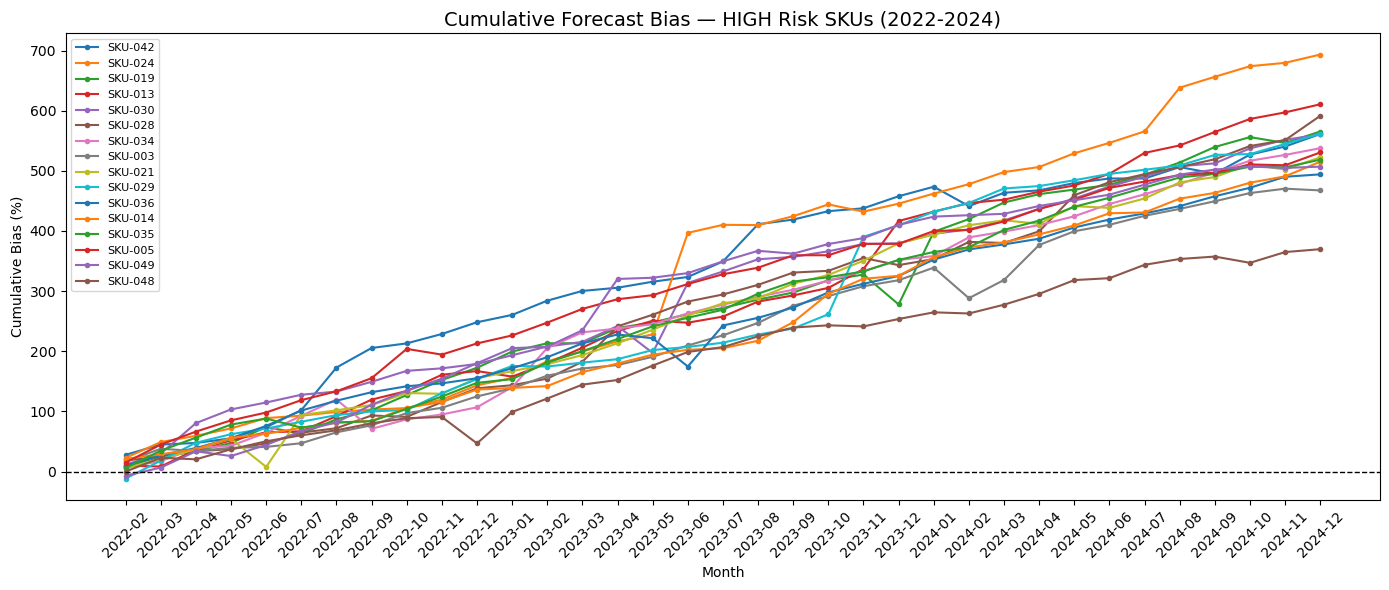


Chart displayed.


In [6]:
#  Cell 6 : Cumulative Bias Trend
# We track bias month by month for HIGH risk SKUs
# A SKU with persistent positive bias over 12+ months is a structural issue, not random noise

# Step 1 - Get HIGH risk SKU list
high_risk_skus = sku_performance[sku_performance["risk_category"] == "HIGH"]["sku_id"].tolist()
print(f"HIGH risk SKUs : {high_risk_skus}")

# Step 2 - Filter main df for HIGH risk SKUs only
df_high = df[df["sku_id"].isin(high_risk_skus)].copy()

# Step 3 - Add month column
df_high["month"] = df_high["week"].dt.to_period("M")

# Step 4 - Calculate monthly bias per SKU
monthly_bias = df_high.groupby(["sku_id", "month"]).agg(
    total_forecast = ("final_forecast", "sum"),
    total_demand   = ("actual_demand", "sum")
).reset_index()

monthly_bias["monthly_bias_pct"] = (
    (monthly_bias["total_forecast"] - monthly_bias["total_demand"]) /
    monthly_bias["total_demand"].replace(0, np.nan) * 100
).round(1)

# Step 5 - Calculate cumulative bias per SKU
monthly_bias["cumulative_bias"] = monthly_bias.groupby("sku_id")["monthly_bias_pct"].cumsum()

# Step 6 - Plot
fig, ax = plt.subplots(figsize=(14, 6))

for sku in high_risk_skus:
    sku_data = monthly_bias[monthly_bias["sku_id"] == sku]
    ax.plot(
        sku_data["month"].astype(str),
        sku_data["cumulative_bias"],
        marker = "o",
        markersize = 3,
        label = sku
    )

ax.axhline(y=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Cumulative Forecast Bias — HIGH Risk SKUs (2022-2024)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Cumulative Bias (%)")
ax.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nChart displayed.")

Global forecast performance by source :
Source  MAPE (%)  Bias (%)
 Sales      10.0       8.9
  Algo      19.7       7.9

Performance by bias flag :
     has_bias  sales_mape  algo_mape  sales_bias  algo_bias
 No bias flag         1.8       20.0        -0.0        7.9
Has bias flag        22.3       19.4        22.3        7.9


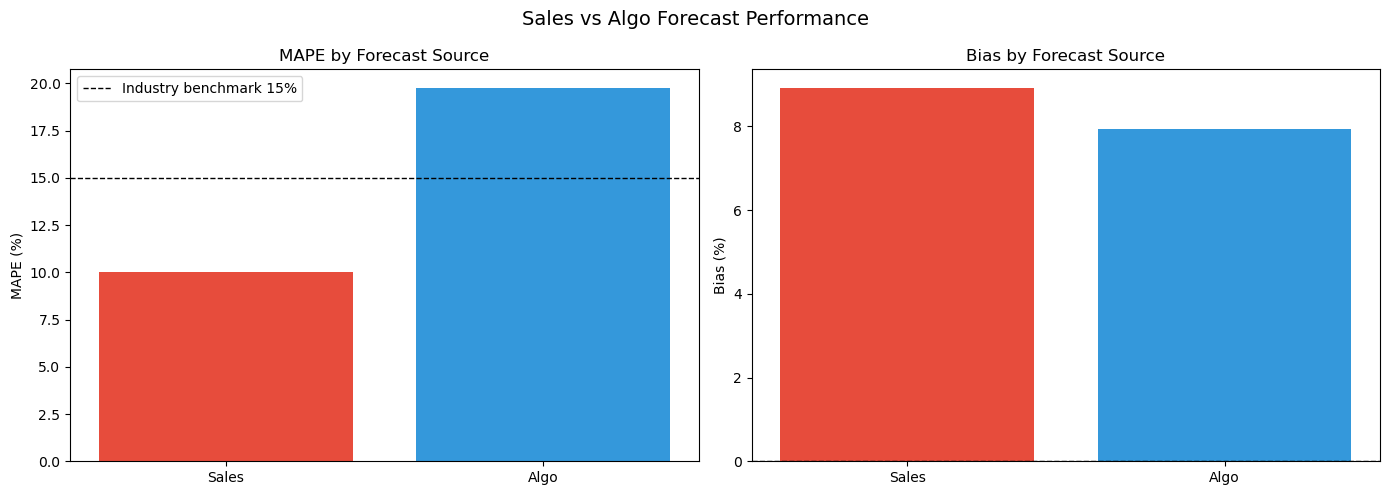

In [7]:
# Cell 7 : Sales vs Algo Forecast Performance 
# Who performs better ? Sales or Algo ?
# And does it depend on the SKU profile (bias flag, seasonality flag) ?

# Step 1 :Calculate error metrics for each source separately
df["sales_error_pct"] = (
    (df["sales_forecast"] - df["actual_demand"]).abs() /
    df["actual_demand"].replace(0, np.nan)
) * 100

df["algo_error_pct"] = (
    (df["algo_forecast"] - df["actual_demand"]).abs() /
    df["actual_demand"].replace(0, np.nan)
) * 100

df["sales_bias_pct"] = (
    (df["sales_forecast"] - df["actual_demand"]) /
    df["actual_demand"].replace(0, np.nan)
) * 100

df["algo_bias_pct"] = (
    (df["algo_forecast"] - df["actual_demand"]) /
    df["actual_demand"].replace(0, np.nan)
) * 100

# Step 2: Global comparison
global_comparison = pd.DataFrame({
    "Source"   : ["Sales", "Algo"],
    "MAPE (%)" : [
        df["sales_error_pct"].mean().round(1),
        df["algo_error_pct"].mean().round(1)
    ],
    "Bias (%)" : [
        df["sales_bias_pct"].mean().round(1),
        df["algo_bias_pct"].mean().round(1)
    ]
})

print("Global forecast performance by source :")
print(global_comparison.to_string(index=False))

# Step 3: Performance by SKU profile
profile_comparison = df.groupby("has_bias").agg(
    sales_mape = ("sales_error_pct", "mean"),
    algo_mape  = ("algo_error_pct", "mean"),
    sales_bias = ("sales_bias_pct", "mean"),
    algo_bias  = ("algo_bias_pct", "mean")
).round(1).reset_index()

profile_comparison["has_bias"] = profile_comparison["has_bias"].map({0: "No bias flag", 1: "Has bias flag"})

print(f"\nPerformance by bias flag :")
print(profile_comparison.to_string(index=False))

# Step 4: Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: MAPE comparison
axes[0].bar(["Sales", "Algo"],
            [df["sales_error_pct"].mean(), df["algo_error_pct"].mean()],
            color=["#e74c3c", "#3498db"])
axes[0].set_title("MAPE by Forecast Source", fontsize=12)
axes[0].set_ylabel("MAPE (%)")
axes[0].axhline(y=15, color="black", linestyle="--", linewidth=1, label="Industry benchmark 15%")
axes[0].legend()

# Chart 2: Bias comparison
axes[1].bar(["Sales", "Algo"],
            [df["sales_bias_pct"].mean(), df["algo_bias_pct"].mean()],
            color=["#e74c3c", "#3498db"])
axes[1].set_title("Bias by Forecast Source", fontsize=12)
axes[1].set_ylabel("Bias (%)")
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1)

plt.suptitle("Sales vs Algo Forecast Performance", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Cell 8 : Save results to SQLite 
# We save sku_performance to the database
# Power BI will read this table directly for the dashboard

# Reopen connection
conn = sqlite3.connect(DB_PATH)

# Save SKU performance table
sku_performance.to_sql(
    name      = "sku_performance",
    con       = conn,
    if_exists = "replace",
    index     = False
)

# Save monthly bias table
monthly_bias["month"] = monthly_bias["month"].astype(str)
monthly_bias.to_sql(
    name      = "monthly_bias",
    con       = conn,
    if_exists = "replace",
    index     = False
)

# Verify
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"Tables in database : {list(tables['name'])}")

for table in tables['name']:
    count = pd.read_sql(f"SELECT COUNT(*) as n FROM {table}", conn).iloc[0]['n']
    print(f"  {table} : {count} rows")

conn.close()
print("\nModule 2 complete.")

Tables in database : ['product_master', 'demand_history', 'forecast_history', 'sku_performance', 'monthly_bias']
  product_master : 50 rows
  demand_history : 7600 rows
  forecast_history : 7600 rows
  sku_performance : 50 rows
  monthly_bias : 560 rows

Module 2 complete.
